The goal of this task is to classify wines into one of three distinct categories (Class 0, 1, or 2)

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load the Wine dataset
wine = load_wine(as_frame=True)
df_wine = wine.frame

print(f"Data Shape (Rows, Columns): {df_wine.shape}\n")
display(df_wine.head())

Data Shape (Rows, Columns): (178, 14)



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Data Cleaning & Preprocessing

In [5]:
# Check for missing values
print( df_wine.info())

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

Exploratory Data Analysis (EDA) & Visualizations

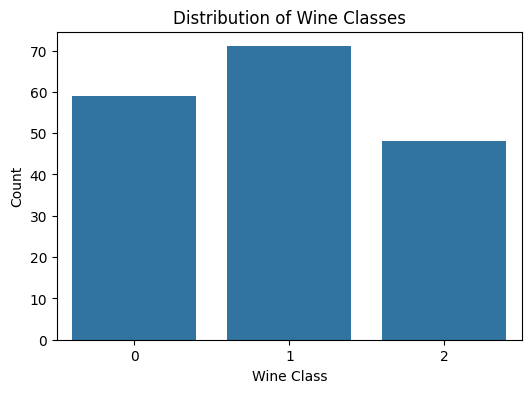

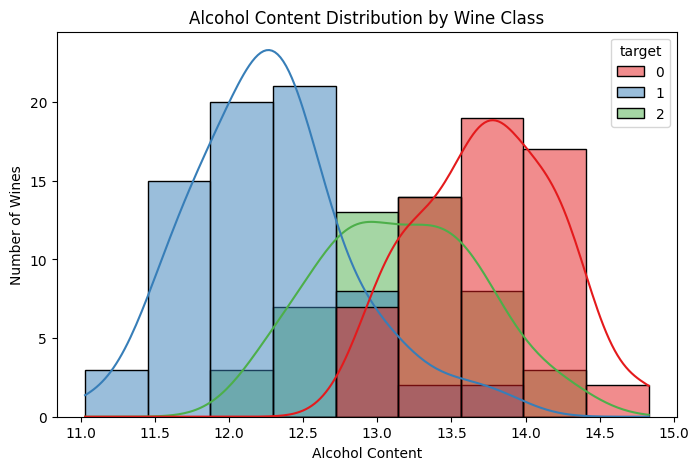

In [6]:
# 1. Visualize the distribution of the target classes
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_wine)
plt.title('Distribution of Wine Classes')
plt.xlabel('Wine Class')
plt.ylabel('Count')
plt.show()



# Visualize Alcohol Content by Wine Class using an overlapping histplot
plt.figure(figsize=(8, 5))
sns.histplot(data=df_wine, x='alcohol', hue='target', palette='Set1', kde=True, alpha=0.5)

plt.title('Alcohol Content Distribution by Wine Class')
plt.xlabel('Alcohol Content')
plt.ylabel('Number of Wines')
plt.show()

Key Insights from EDA
* zero missing values
* dataset is fairly well-balanced. Class 1 has slightly more samples than the others
* Alcohol content is a great distinguishing feature. Class 0 generally has the highest alcohol content, Class 1 has the lowest, and Class 2 sits in the middle.

Model Training & Evaluation

In [7]:
# Import the Pipeline module
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# 1. Separate features (X) and target (y)
X = df_wine.drop('target', axis=1)
y = df_wine['target']

# 2. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:

# 3. Build the Pipeline!
# Step 1: 'scaler' applies StandardScaler
# Step 2: 'classifier' runs the Logistic Regression
wine_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression( max_iter=1000))
])

# 4. Train the Pipeline
wine_pipeline.fit(X_train, y_train)

# 5. Make predictions
wine_preds = wine_pipeline.predict(X_test)

# 6. Evaluate the model
accuracy = accuracy_score(y_test, wine_preds)

print("--- Pipeline Logistic Regression Results ---")
print(f"Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, wine_preds))


--- Pipeline Logistic Regression Results ---
Accuracy: 100.00%

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



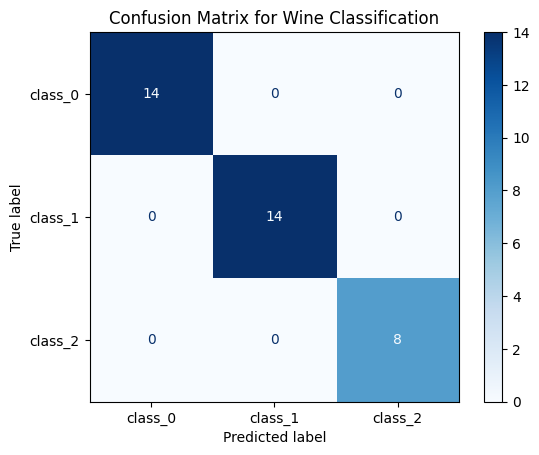

In [10]:

# Display the Confusion Matrix visually
cm = confusion_matrix(y_test, wine_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Wine Classification")
plt.grid(False) # Turns off the seaborn grid lines for the matrix
plt.show()

## Decision Tree Classification

In [11]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Create a Pipeline: Step 1 = Scale Data, Step 2 = Decision Tree
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),  # Optional for trees, but good practice
    ('model', DecisionTreeClassifier(
        max_depth=3,               # Tuning: Best way to prevent overfitting!
        min_samples_leaf=5,        # Leaves must have at least 5 samples
        random_state=42
    ))
])

# Train the pipeline
pipeline_dt.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [12]:
# Predict
y_pred_train = pipeline_dt.predict(X_train)
y_pred_test = pipeline_dt.predict(X_test)

# Evaluate
print("Train Accuracy:", round(accuracy_score(y_train, y_pred_train), 3))
print("Test Accuracy: ", round(accuracy_score(y_test, y_pred_test), 3))

Train Accuracy: 0.972
Test Accuracy:  0.944


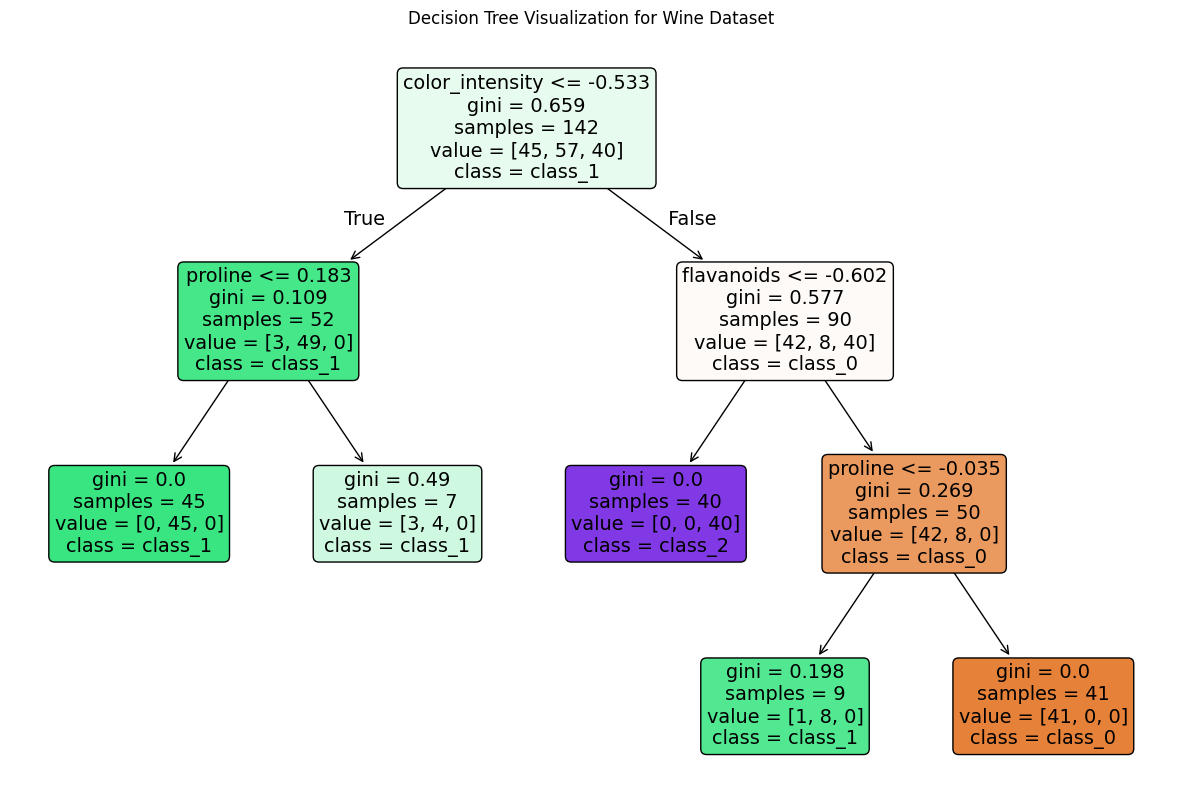

In [19]:
plt.figure(figsize=(15, 10))
plot_tree(pipeline_dt.named_steps['model'], 
          feature_names=X.columns, 
          class_names=wine.target_names, 
          filled=True,rounded=True)
plt.title("Decision Tree Visualization for Wine Dataset")
plt.show()